# Polynomial Regression: Linear vs Nonlinear Relationships

This notebook demonstrates:

- Why polynomial regression can be used instead of linear regression.
- How to generate random nonlinear data.
- How to add Gaussian noise.
- How linear regression performs on curved data.
- How polynomial regression captures the nonlinear relationship.
- How to visualize the models.
- How to evaluate both models using MSE and R².
- How polynomial degree affects underfitting and overfitting.

We use `scikit-learn`, `numpy`, `pandas`, and `matplotlib`.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Make results reproducible
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Generate Random Nonlinear Data

We will create data from the nonlinear relationship:

`y = 2x² + 3x + 5`

Then we add random Gaussian noise.

The noise makes the dataset more realistic because real-world data rarely follows a perfect mathematical equation.

In [2]:
# Number of samples
n_samples = 100

# Generate X values
X = np.linspace(-5, 5, n_samples).reshape(-1, 1)

# True nonlinear relationship
y_true = 2 * X**2 + 3 * X + 5

# Generate random Gaussian noise
noise = np.random.normal(
    loc=0,
    scale=8,
    size=(n_samples, 1)
)

# Observed target values
y = y_true + noise

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 1)
y shape: (100, 1)


In [3]:

data = pd.DataFrame({
    "X": X.ravel(),
    "True_y": y_true.ravel(),
    "Noise": noise.ravel(),
    "Observed_y": y.ravel()
})

display(data.head(10))

,X,True_y,Noise,Observed_y
0,-5.000000,40.000000,3.973713,43.973713
1,-4.898990,38.303234,-1.106114,37.197120
2,-4.797980,36.647281,5.181508,41.828789
3,-4.696970,35.032140,12.184239,47.216378
4,-4.595960,33.457810,-1.873227,31.584583
5,-4.494949,31.924293,-1.873096,30.051198
6,-4.393939,30.431589,12.633703,43.065291
7,-4.292929,28.979696,6.139478,35.119174
8,-4.191919,27.568615,-3.755795,23.812820
9,-4.090909,26.198347,4.340480,30.538827


## 2. Visualize the Generated Data

The scatter points represent our noisy observations.

The smooth curve represents the original relationship before noise was added.

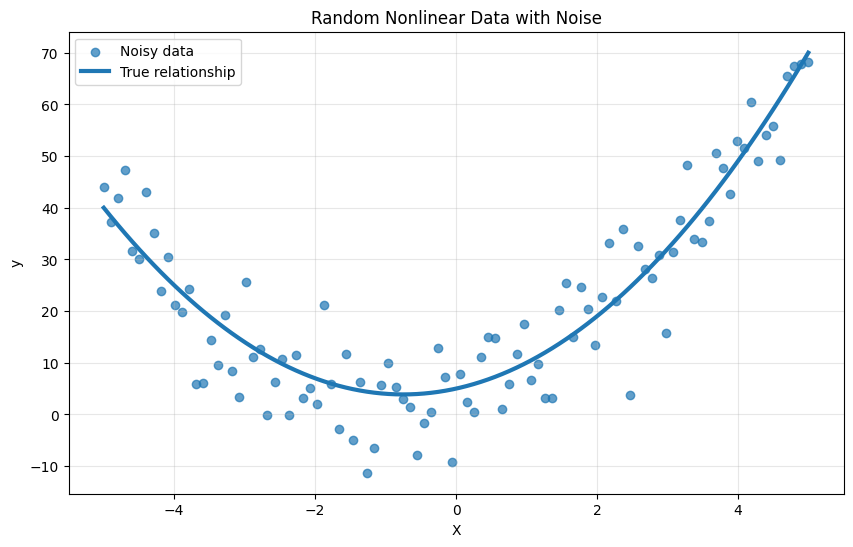

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.7,
    label="Noisy data"
)

plt.plot(
    X,
    y_true,
    linewidth=3,
    label="True relationship"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Random Nonlinear Data with Noise")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 3. Why Linear Regression Is Not Enough

A simple linear regression model assumes:

`y = b₀ + b₁x`

This creates a straight line.

Our generated data has a curved relationship, approximately:

`y = 2x² + 3x + 5`

Therefore, a straight line cannot properly capture the pattern.

In [5]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [6]:
# Train a simple Linear Regression model

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

# Predictions
linear_predictions = linear_model.predict(X_test)

print("Linear Regression coefficient:", linear_model.coef_[0][0])
print("Linear Regression intercept:", linear_model.intercept_[0])

Linear Regression coefficient: 3.4742621740372956
Linear Regression intercept: 21.03253514375991


## 4. Visualize Linear Regression

Notice that the linear model tries to find the best straight line through the curved data.

This is an example of **underfitting**: the model is too simple to capture the underlying relationship.

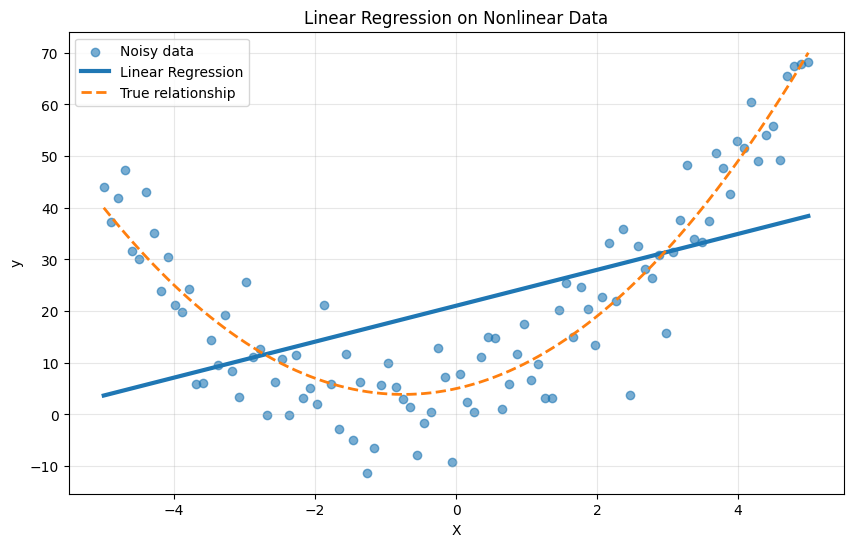

In [7]:
# Create smooth X values for plotting
X_curve = np.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1, 1)

# Linear model prediction over the complete range
linear_curve = linear_model.predict(X_curve)

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.6,
    label="Noisy data"
)

plt.plot(
    X_curve,
    linear_curve,
    linewidth=3,
    label="Linear Regression"
)

plt.plot(
    X,
    y_true,
    linewidth=2,
    linestyle="--",
    label="True relationship"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression on Nonlinear Data")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 5. Polynomial Regression

Polynomial regression solves the limitation by creating additional features.

For degree 2:

`X → X, X²`

Linear regression can then learn:

`y = b₀ + b₁x + b₂x²`

For degree 3:

`X → X, X², X³`

and the model becomes:

`y = b₀ + b₁x + b₂x² + b₃x³`

The model is still linear with respect to its coefficients, but it can represent a nonlinear relationship with respect to `X`.

In [8]:
# Create Polynomial Regression model with degree 2

polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(degree=2)
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

# Train model
polynomial_model.fit(
    X_train,
    y_train
)

# Test predictions
polynomial_predictions = polynomial_model.predict(X_test)

print("Polynomial Regression degree: 2")

Polynomial Regression degree: 2


## 6. Visualize Polynomial Regression

The polynomial model can bend to follow the curvature of the data.

This should provide a much better fit than the straight-line model.

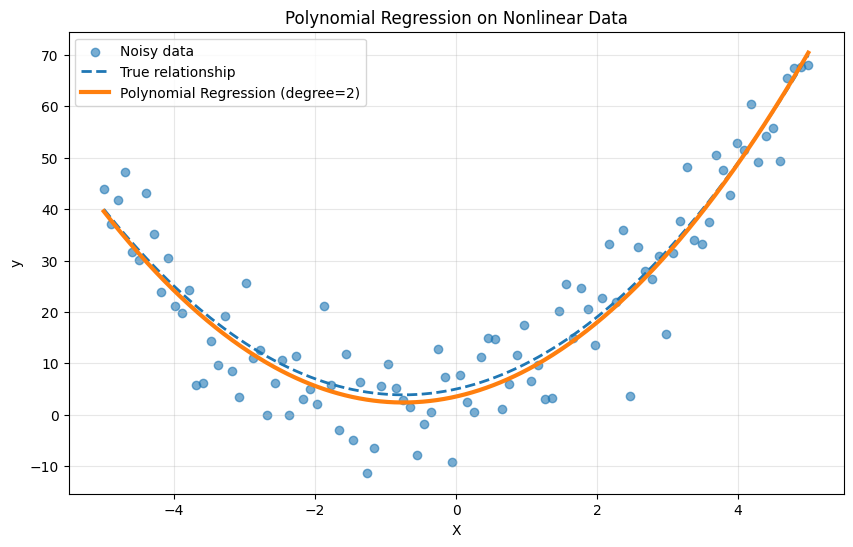

In [9]:
# Polynomial predictions across the complete X range

polynomial_curve = polynomial_model.predict(X_curve)

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.6,
    label="Noisy data"
)

plt.plot(
    X,
    y_true,
    linewidth=2,
    linestyle="--",
    label="True relationship"
)

plt.plot(
    X_curve,
    polynomial_curve,
    linewidth=3,
    label="Polynomial Regression (degree=2)"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression on Nonlinear Data")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7. Linear Regression vs Polynomial Regression

Now we compare both models on the same graph.

The main question is:

**Which model captures the nonlinear pattern better?**

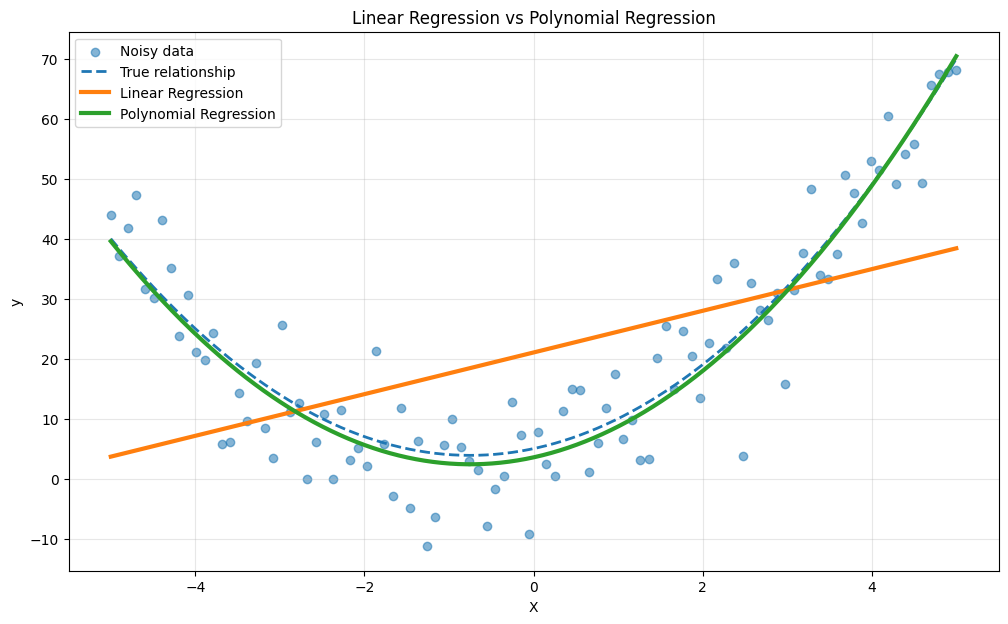

In [10]:
plt.figure(figsize=(12, 7))

# Original data
plt.scatter(
    X,
    y,
    alpha=0.55,
    label="Noisy data"
)

# True relationship
plt.plot(
    X,
    y_true,
    linewidth=2,
    linestyle="--",
    label="True relationship"
)

# Linear model
plt.plot(
    X_curve,
    linear_curve,
    linewidth=3,
    label="Linear Regression"
)

# Polynomial model
plt.plot(
    X_curve,
    polynomial_curve,
    linewidth=3,
    label="Polynomial Regression"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression vs Polynomial Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Evaluate Both Models

We use:

### Mean Squared Error (MSE)

Lower MSE is better.

### R² Score

Higher R² is generally better.

We evaluate on the test set so that the comparison measures performance on data the models did not train on.

In [11]:
# Calculate metrics

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

polynomial_mse = mean_squared_error(
    y_test,
    polynomial_predictions
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

polynomial_r2 = r2_score(
    y_test,
    polynomial_predictions
)

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression (degree=2)"
    ],
    "Test MSE": [
        linear_mse,
        polynomial_mse
    ],
    "Test R²": [
        linear_r2,
        polynomial_r2
    ]
})

display(results)

,Model,Test MSE,Test R²
0,Linear Regression,255.896645,-0.027431
1,Polynomial Regression (degree=2),39.656515,0.840778


## 9. Experiment: Different Polynomial Degrees

Polynomial degree controls model complexity.

- Degree 1 → straight line.
- Degree 2 → quadratic curve.
- Degree 3 → cubic curve.
- Higher degrees → increasingly flexible models.

Very high degrees can memorize noise and cause **overfitting**.

We will compare degrees 1, 2, 3, 5, 10, and 20.

In [12]:
degrees = [1, 2, 3, 5, 10, 20]

degree_results = []

for degree in degrees:

    model = Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(degree=degree)
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    degree_results.append({
        "Degree": degree,
        "Train MSE": mean_squared_error(y_train, train_pred),
        "Test MSE": mean_squared_error(y_test, test_pred),
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred)
    })

degree_results = pd.DataFrame(degree_results)

display(degree_results)

,Degree,Train MSE,Test MSE,Train R²,Test R²
0,1,308.627008,255.896645,0.249569,-0.027431
1,2,55.056501,39.656515,0.866129,0.840778
2,3,52.225537,38.543818,0.873013,0.845246
3,5,51.019789,41.544067,0.875945,0.833200
4,10,47.955580,52.306014,0.883395,0.789990
5,20,45.098721,287.078858,0.890342,-0.152628


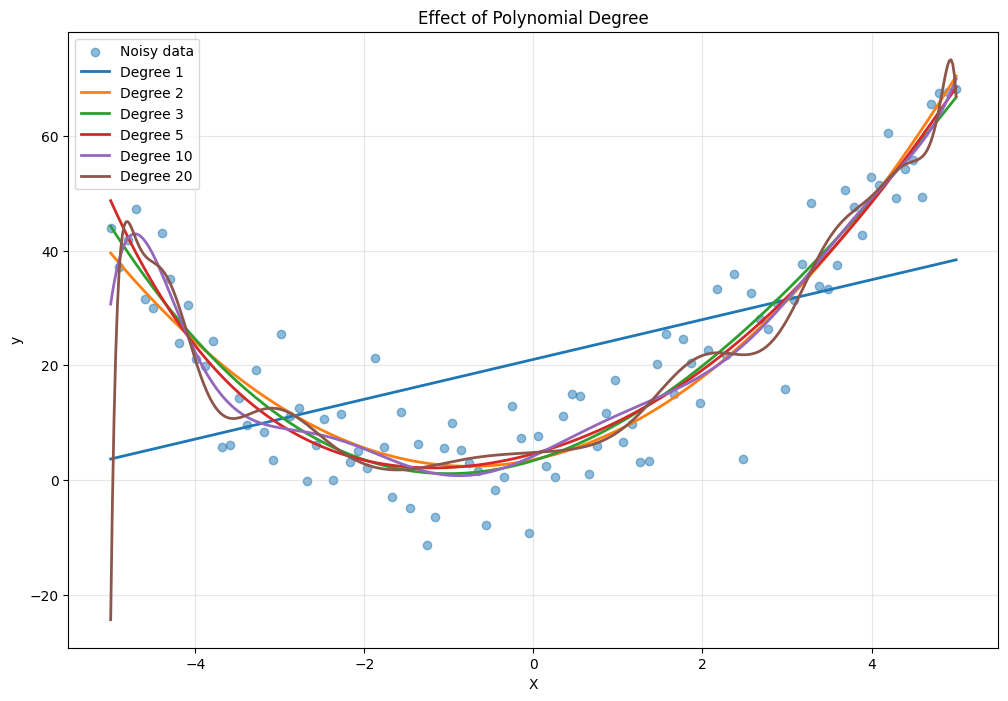

In [13]:
# Plot models with different polynomial degrees

plt.figure(figsize=(12, 8))

plt.scatter(
    X,
    y,
    alpha=0.5,
    label="Noisy data"
)

for degree in degrees:

    model = Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(degree=degree)
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_curve)

    plt.plot(
        X_curve,
        predictions,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Effect of Polynomial Degree")
plt.legend()
plt.grid(alpha=0.3)

plt.show()